In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from zipfile import ZipFile


In [2]:
zip_path = "/content/animal_dataset.zip"
extract_path = "/content/animal_dataset"

with ZipFile(zip_path, "r") as z:
    z.extractall("/content/")

print("Extracted to:", extract_path)
print("Folders inside extracted directory:", os.listdir(extract_path))


Extracted to: /content/animal_dataset
Folders inside extracted directory: ['panda', 'dog', 'cat']


In [3]:
classes = []

for item in os.listdir(extract_path):
    folder = os.path.join(extract_path, item)
    if os.path.isdir(folder):
        classes.append(item)

print("Detected Classes:", classes)


Detected Classes: ['panda', 'dog', 'cat']


In [4]:
img_size = 32
X = []
Y = []

for label, cls in enumerate(classes):
    folder = os.path.join(extract_path, cls)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        X.append(img.flatten())
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Loaded images:", X.shape)
print("Labels:", Y.shape)


Loaded images: (300, 1024)
Labels: (300,)


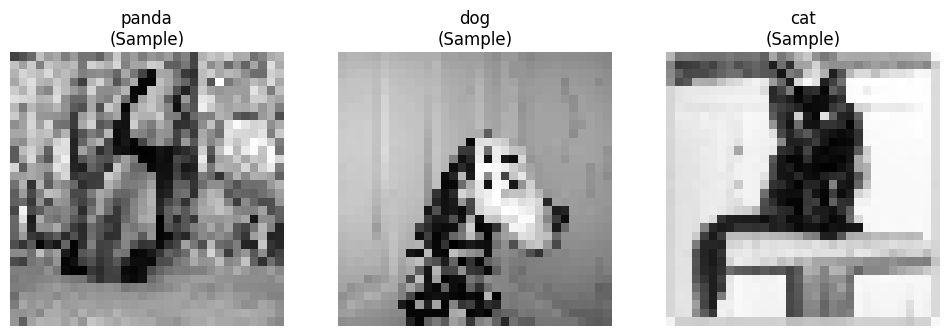

In [5]:
plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):
    folder = os.path.join(extract_path, cls)
    sample_img = os.listdir(folder)[0]
    img = cv2.imread(os.path.join(folder, sample_img), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (32, 32))

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{cls}\n(Sample)")
    plt.axis("off")

plt.show()


In [6]:
def L1_distance(a, b):
    return np.sum(np.abs(a - b))

def L2_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))


In [7]:
def knn_predict(x, X_train, Y_train, k, dist="L2"):
    distances = []

    for i in range(len(X_train)):
        if dist == "L1":
            d = L1_distance(x, X_train[i])
        else:
            d = L2_distance(x, X_train[i])
        distances.append((d, Y_train[i]))

    distances.sort(key=lambda z: z[0])
    k_labels = [label for _, label in distances[:k]]

    vals, counts = np.unique(k_labels, return_counts=True)
    return vals[np.argmax(counts)]


In [8]:
def five_fold_split(X, Y):
    idx = np.arange(len(X))
    np.random.shuffle(idx)

    fold_size = len(X) // 5
    folds = []

    for i in range(5):
        val = idx[i*fold_size : (i+1)*fold_size]
        train = np.setdiff1d(idx, val)
        folds.append((train, val))

    return folds

folds = five_fold_split(X, Y)


In [9]:
K_values = [1, 3, 5, 7, 9]

acc_L1 = []
acc_L2 = []

for k in K_values:
    fold_acc_L1 = []
    fold_acc_L2 = []

    for train_idx, val_idx in folds:
        X_train, Y_train = X[train_idx], Y[train_idx]
        X_val, Y_val = X[val_idx], Y[val_idx]

        preds_L1 = []
        preds_L2 = []

        for x in X_val:
            preds_L1.append(knn_predict(x, X_train, Y_train, k, "L1"))
            preds_L2.append(knn_predict(x, X_train, Y_train, k, "L2"))

        fold_acc_L1.append(np.mean(np.array(preds_L1) == Y_val))
        fold_acc_L2.append(np.mean(np.array(preds_L2) == Y_val))

    acc_L1.append(np.mean(fold_acc_L1))
    acc_L2.append(np.mean(fold_acc_L2))

print("L1 Accuracies:", acc_L1)
print("L2 Accuracies:", acc_L2)


L1 Accuracies: [np.float64(0.41000000000000003), np.float64(0.42666666666666664), np.float64(0.4333333333333333), np.float64(0.4366666666666667), np.float64(0.4366666666666667)]
L2 Accuracies: [np.float64(0.3833333333333333), np.float64(0.39), np.float64(0.42666666666666675), np.float64(0.4133333333333333), np.float64(0.38666666666666666)]


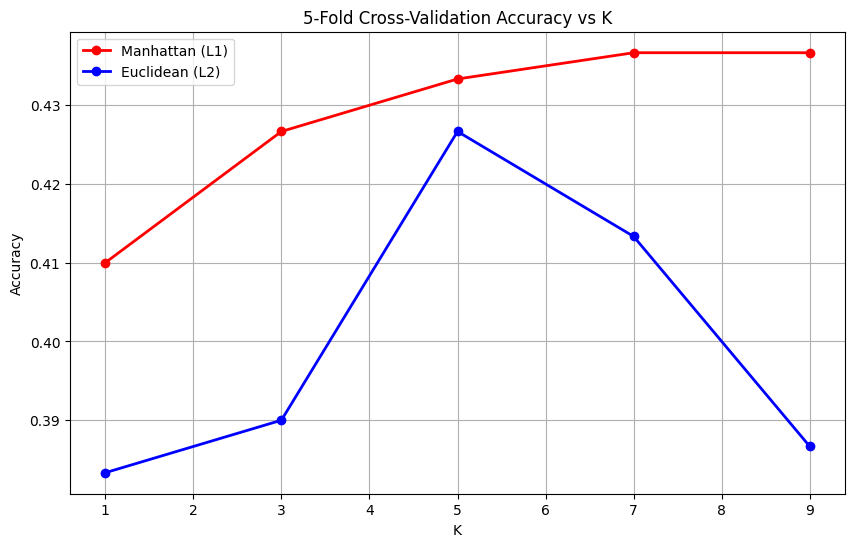

In [10]:
plt.figure(figsize=(10,6))
plt.plot(K_values, acc_L1, marker='o', linewidth=2, label="Manhattan (L1)", color='red')
plt.plot(K_values, acc_L2, marker='o', linewidth=2, label="Euclidean (L2)", color='blue')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy vs K")
plt.grid(True)
plt.legend()
plt.show()


In [11]:
def top5(x, X_train, Y_train, dist="L2"):
    dlist = []

    for i in range(len(X_train)):
        if dist == "L1":
            d = L1_distance(x, X_train[i])
        else:
            d = L2_distance(x, X_train[i])
        dlist.append((d, Y_train[i]))

    dlist.sort(key=lambda z: z[0])
    return dlist[:5]


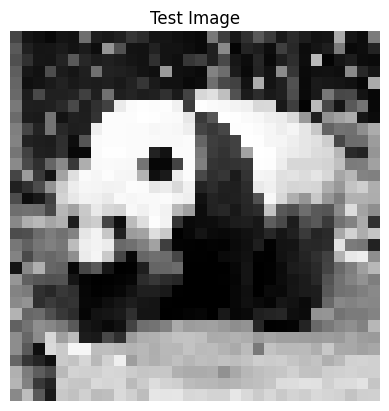


Top-5 predictions:
panda → distance: 0.0
cat → distance: 316.56278998012385
dog → distance: 316.6433324736209
panda → distance: 318.19962287846914
panda → distance: 318.3834166535688


In [12]:
test_index = 10
img = X[test_index].reshape(32,32)

plt.imshow(img, cmap='gray')
plt.title("Test Image")
plt.axis("off")
plt.show()

print("\nTop-5 predictions:")
for d, label in top5(X[test_index], X, Y, "L2"):
    print(classes[label], "→ distance:", d)
